In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, validation_curve, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import DecompensationImputed

In [2]:
X, y = DecompensationImputed.load_data(sample_size=100000, icu_vitals=True, top_n_labs=230, top_n_drugs=954, top_n_procedures=55)

Returing 100000 patient records with 675 columns. y distribution: 
0    0.97126
1    0.02874
Name: proportion, dtype: float64


In [3]:
# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 675), Test: (20000, 675)


In [4]:
print(X.shape)
X.head(20)

(100000, 675)


,los_hours,anchor_age,gender_female,bp_systolic,bp_diastolic,result_value_x,result_value_y,vital_heart_rate,vital_respiratory_rate,vital_spo2,...,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN
0,107.516667,57,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
1,94.216667,65,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
2,80.533333,43,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,0,0,0,0,0
3,79.000000,41,1,124.0,72.0,170.0,64.0,82.5,19.131007,96.4,...,0,0,0,0,0,0,0,0,0,0
4,89.366667,35,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
5,312.683333,63,0,124.0,72.0,170.0,72.0,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
6,274.283333,56,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
7,113.716667,39,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,0,0,0,0,0
8,271.850000,26,1,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0
9,163.300000,50,0,124.0,72.0,170.0,65.5,82.5,19.131007,96.4,...,0,0,0,0,0,1,0,0,0,0


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Decision Tree (validation curve over max_depth)

In [6]:
param_range =  [3,5,7,10,15,20,30,50,100,500]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
mean_val = val_scores.mean(axis=1)
best_depth = param_range[np.argmax(mean_val)]
print("best max_depth:", best_depth)

best max_depth: 5


In [7]:
decision_tree_model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       15347     4078   (specificity 0.790)
  Actual 1          97      478   (sensitivity 0.831)

TPR (sensitivity):  0.831
FPR (fall-out):     0.210
Precision:          0.105
ROC-AUC:            0.888

              precision    recall  f1-score   support

    Survived       0.99      0.79      0.88     19425
        Died       0.10      0.83      0.19       575

    accuracy                           0.79     20000
   macro avg       0.55      0.81      0.53     20000
weighted avg       0.97      0.79      0.86     20000



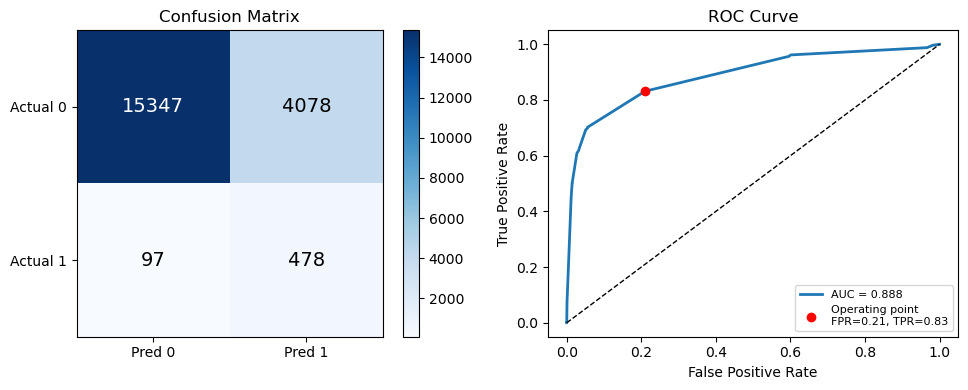

In [8]:
y_pred  = decision_tree_model.predict(X_test_scaled)
y_proba = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Decision Tree (unbounded depth)

In [9]:
decision_tree_max_depth = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19143      282   (specificity 0.985)
  Actual 1         268      307   (sensitivity 0.534)

TPR (sensitivity):  0.534
FPR (fall-out):     0.015
Precision:          0.521
ROC-AUC:            0.760

              precision    recall  f1-score   support

    Survived       0.99      0.99      0.99     19425
        Died       0.52      0.53      0.53       575

    accuracy                           0.97     20000
   macro avg       0.75      0.76      0.76     20000
weighted avg       0.97      0.97      0.97     20000



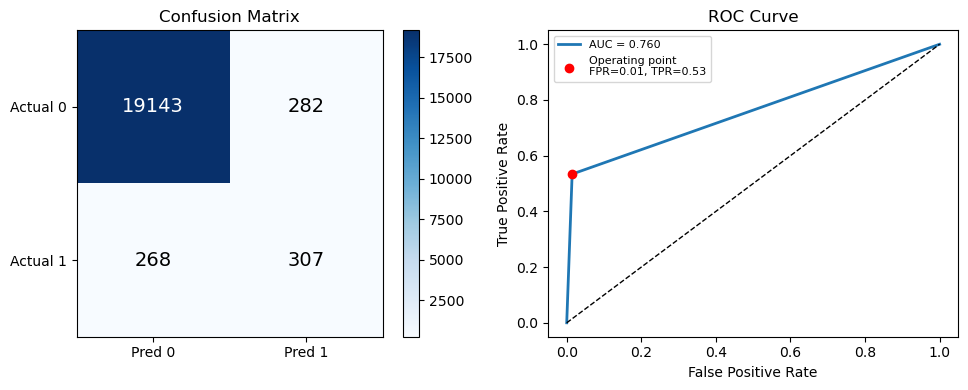

In [10]:
y_pred  = decision_tree_max_depth.predict(X_test_scaled)
y_proba = decision_tree_max_depth.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Random Forest

In [11]:
random_forest = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    verbose=2,
    n_jobs=-1).fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 6 of 100
building tree 3 of 100
building tree 2 of 100
building tree 7 of 100
building tree 5 of 100
building tree 10 of 100
building tree 11 of 100
building tree 1 of 100
building tree 12 of 100
building tree 8 of 100
building tree 9 of 100
building tree 4 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.5s


building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.3s finished


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19038      387   (specificity 0.980)
  Actual 1         138      437   (sensitivity 0.760)

TPR (sensitivity):  0.760
FPR (fall-out):     0.020
Precision:          0.530
ROC-AUC:            0.963

              precision    recall  f1-score   support

    Survived       0.99      0.98      0.99     19425
        Died       0.53      0.76      0.62       575

    accuracy                           0.97     20000
   macro avg       0.76      0.87      0.81     20000
weighted avg       0.98      0.97      0.98     20000



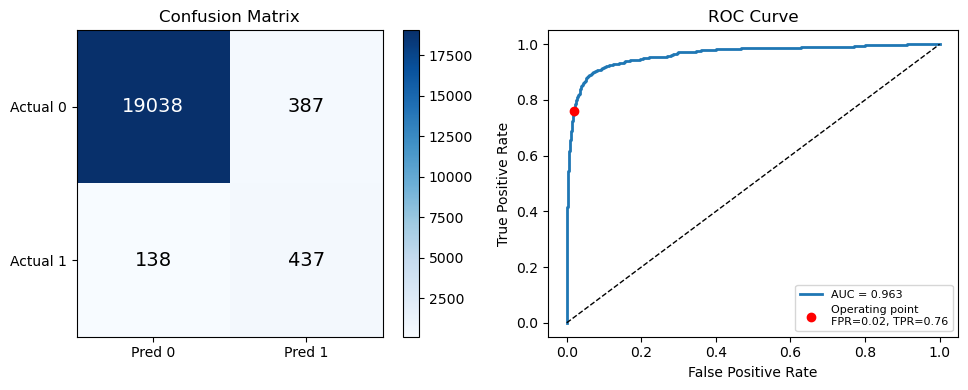

In [12]:
y_pred  = random_forest.predict(X_test_scaled)
y_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## RandomizedSearchCV

In [ ]:
clf = RandomForestClassifier(n_jobs=-1, random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [3, 5, 20, 30, None],
    "max_features": ["sqrt", 0.2, 0.5],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20, 50],
    "bootstrap": [True],
}

rs = RandomizedSearchCV(clf, param_dist, n_iter=100, cv=5, scoring="roc_auc", n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print(rs.best_params_)

/nix/store/nznbj6myf341l5dd9scglfnycw3h2jbh-python3-3.13.12-env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
